# Print-in-place bolt and nut

Bolt 100 mm tall / 30 mm thread with a nut printed in place around the shaft - one plate, no supports. The unscrew motion check helically drives the real nut over the real bolt.

**How this works:** you run the cells (Shift+Enter, top to bottom); the agent writes and fixes `model.py` next to this notebook. The notebook never calls the agent - when something needs a design change, annotate the renders (step 3) or describe it in chat, and re-run after the agent updates the model. All assets live in this folder: `model.py`, `outputs/` (renders, reports, STL print files), `annotations.json`.

## 1. The need

*Edit me.* What the part must do, where it mounts, loads, material. Reference files go in this folder with source + license noted.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parents[1] / 'src'))
from agentic_cad.runner import run
from agentic_cad.study import run_study
from agentic_cad.nb import show_run, show_annotations

PROFILE = Path.cwd().parents[1] / 'profiles' / 'elegoo_cc2_pla.json'
MODEL = Path.cwd() / 'model.py'
OUT = Path.cwd() / 'outputs'

## 2. Build and verify

Runs the model through the evidence gates (B-rep, mesh integrity, motion, clearance) and renders it. Re-run this cell after every model change.

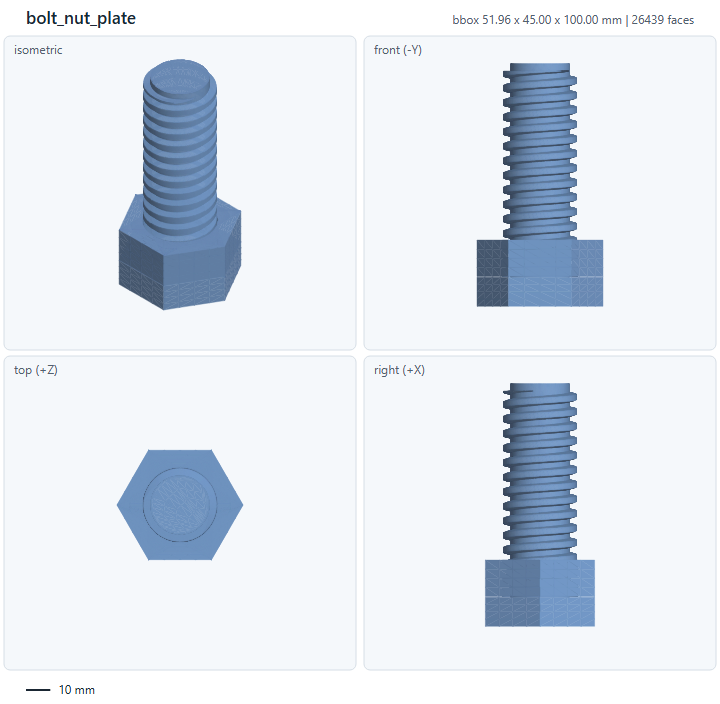

In [2]:
report_path, report = run(MODEL, PROFILE, OUT, enable_slicer=False, enable_freecad=False, enable_raster=True)
show_run(report)

## 3. Annotate what to change

Open the `annotate:` file shown above in a browser, pin comments on the views, export `annotations.json` into this folder, then run the next cell and hand the result to the agent.

In [3]:
# pins = show_annotations(Path.cwd() / 'annotations.json')

## 4. Unsure about a parameter? Sweep it


In [4]:
# _, study = run_study(MODEL, PROFILE, OUT / 'studies',
#     {'wall_mm': [2.0, 2.4, 3.0]}, minimize='total_volume_mm3')
# print(study['recommended'])

## 5. Release

Full gates: FreeCAD STEP round-trip + the real slicer. Print files: STLs in `outputs/<design>/`, G-code under `outputs/<design>/slicer/`.

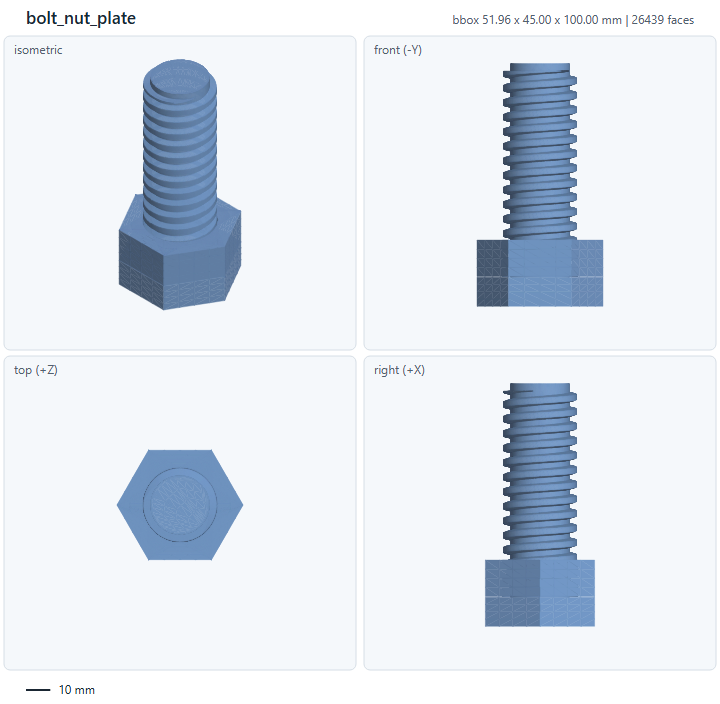

bolt_nut_plate | STL: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\bolt-nut-print-in-place\outputs\bolt_nut_print_in_place\bolt_nut_plate.stl | slicer: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\bolt-nut-print-in-place\outputs\bolt_nut_print_in_place\slicer\bolt_nut_plate\plate_1.gcode


In [5]:
report_path, report = run(MODEL, PROFILE, OUT, enable_raster=True)
show_run(report)
for part in report['parts']:
    print(part['name'], '| STL:', part['artifacts']['stl'], '| slicer:', part['slicer'].get('gcode', part['slicer']['status']))